# Project 2 — House Price Prediction

**Type:** Regression  
**Dataset:** California Housing (scikit-learn built-in)  
**Goal:** Predict median house prices from census block features

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/03_projects/house_price/house_price.ipynb)

---

## Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Load and Inspect Data](#2-load-and-inspect-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Build Preprocessing Pipeline](#5-build-preprocessing-pipeline)
6. [Train and Compare Models](#6-train-and-compare-models)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Final Model Evaluation](#8-final-model-evaluation)
9. [Residual Analysis](#9-residual-analysis)
10. [Feature Importance and Insights](#10-feature-importance-and-insights)
11. [Key Takeaways](#11-key-takeaways)


## 1. Problem Statement

The California Housing dataset contains data from the 1990 California census. Each row represents one census block group (roughly 600–3000 people).

**Task:** Predict `MedHouseVal` — median house value in $100,000 units

**Evaluation metric:** RMSE and R² (primary), MAE (secondary)

**Features available:**

| Feature | Description |
|---|---|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in years |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |

**Target:** `MedHouseVal` — median house value (capped at 5.0 = $500,000)


## 2. Load and Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f'Shape: {df.shape}')
print(f'\nFeature descriptions:')
for name, desc in zip(housing.feature_names, housing.feature_names):
    print(f'  {name}')
print(f'\nTarget: {housing.target_names[0]}')
df.head()


Shape: (20640, 9)

Feature descriptions:
  MedInc
  HouseAge
  AveRooms
  AveBedrms
  Population
  AveOccup
  Latitude
  Longitude

Target: MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)
print('\nNumeric summary:')
df.describe().round(3)


Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Numeric summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


## 3. Exploratory Data Analysis

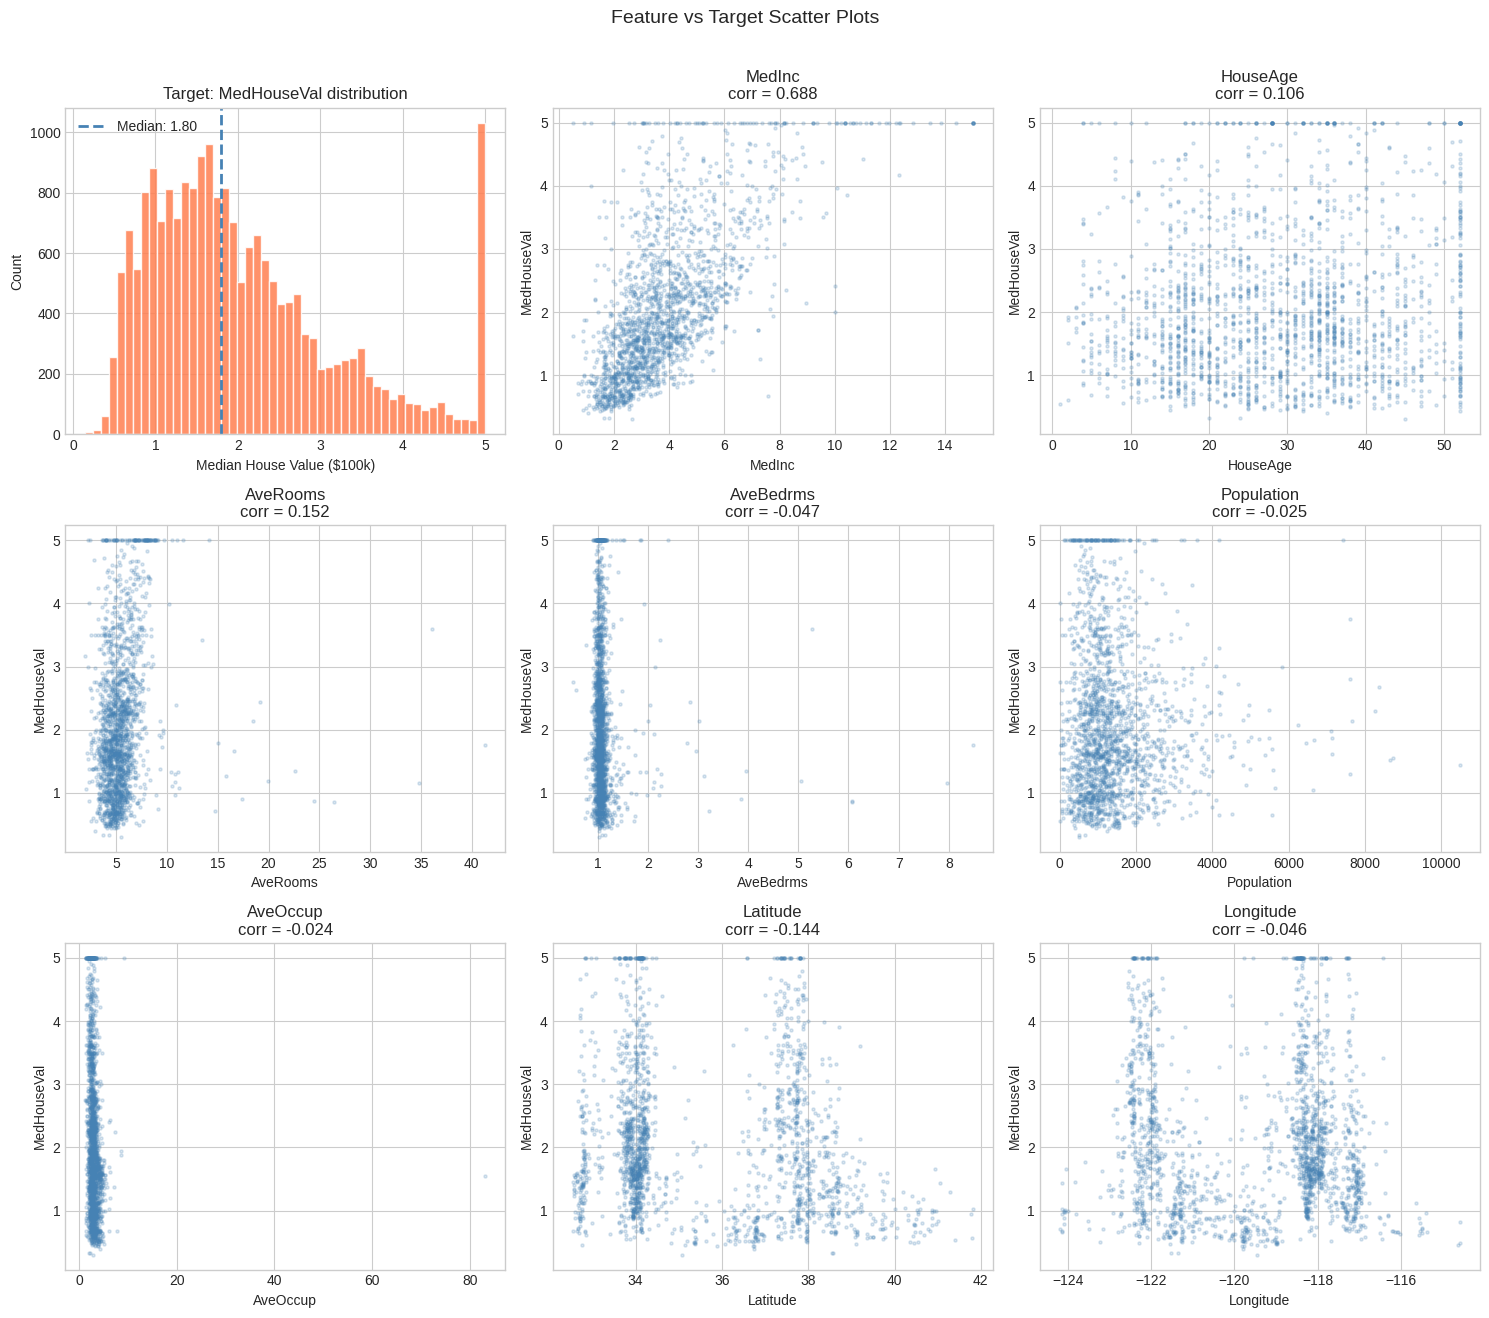

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

feature_cols = housing.feature_names

# Target distribution
axes[0].hist(df['MedHouseVal'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('Target: MedHouseVal distribution')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['MedHouseVal'].median(), color='steelblue',
                linewidth=2, linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].legend()

# Scatter: each feature vs target
for i, feat in enumerate(feature_cols, 1):
    sample = df.sample(2000, random_state=42)
    axes[i].scatter(sample[feat], sample['MedHouseVal'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('MedHouseVal')
    # Correlation
    corr = df[[feat, 'MedHouseVal']].corr().iloc[0,1]
    axes[i].set_title(f'{feat}\ncorr = {corr:.3f}')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


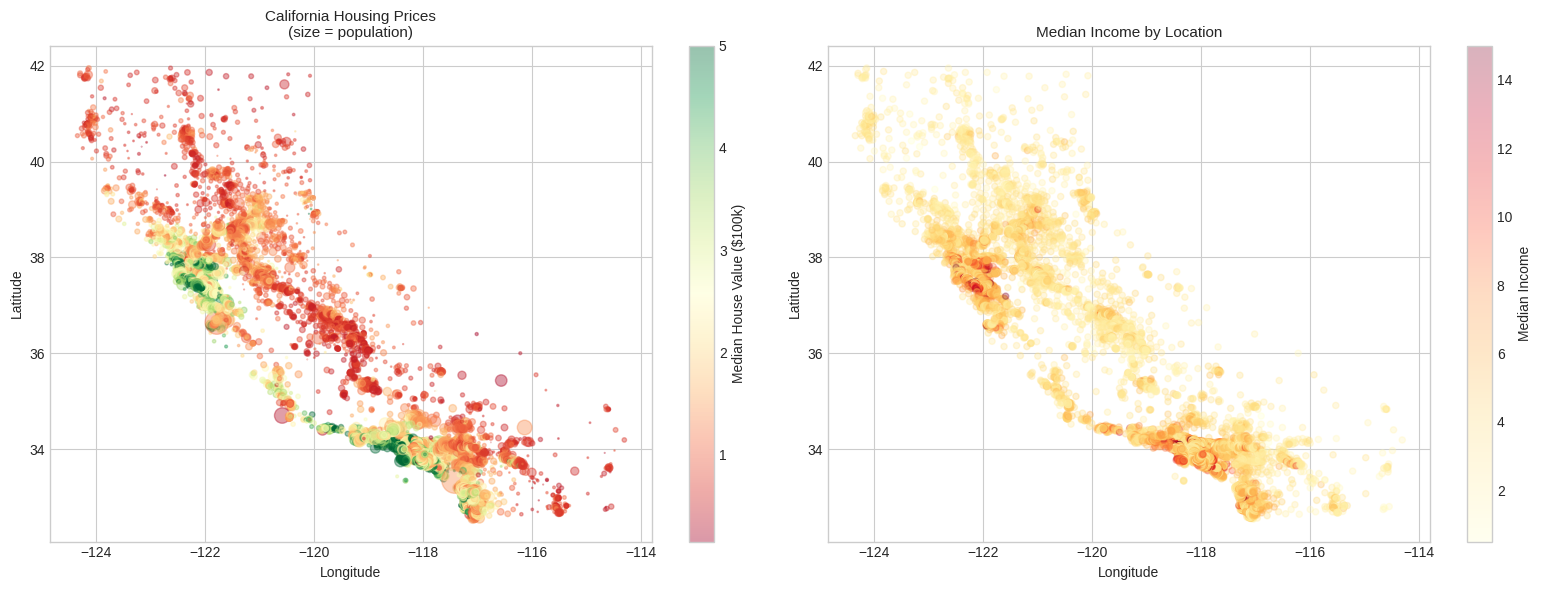

In [4]:
# Geographic visualization — price map
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price map
sc1 = axes[0].scatter(df['Longitude'], df['Latitude'],
                       c=df['MedHouseVal'], cmap='RdYlGn',
                       s=df['Population']/100, alpha=0.4)
plt.colorbar(sc1, ax=axes[0], label='Median House Value ($100k)')
axes[0].set_title('California Housing Prices\n(size = population)', fontsize=11)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# Income map
sc2 = axes[1].scatter(df['Longitude'], df['Latitude'],
                       c=df['MedInc'], cmap='YlOrRd',
                       s=20, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Median Income')
axes[1].set_title('Median Income by Location', fontsize=11)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


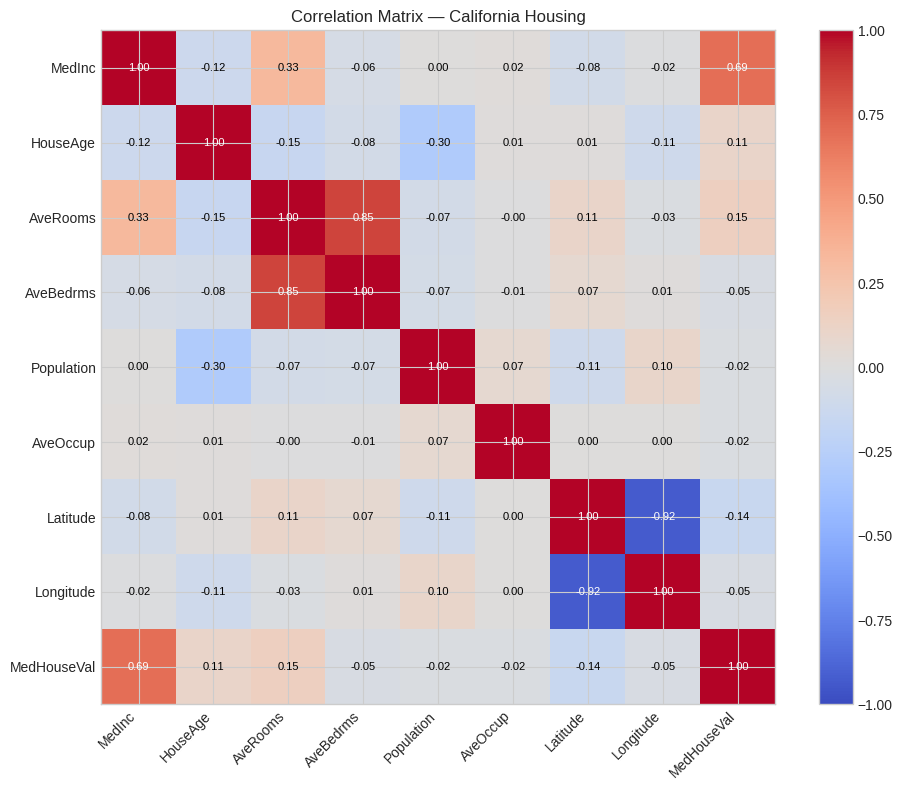

Features most correlated with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160


In [5]:
# Correlation heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
cols_c = corr.columns.tolist()
ax.set_xticks(range(len(cols_c))); ax.set_yticks(range(len(cols_c)))
ax.set_xticklabels(cols_c, rotation=45, ha='right')
ax.set_yticklabels(cols_c)
for i in range(len(cols_c)):
    for j in range(len(cols_c)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
ax.set_title('Correlation Matrix — California Housing', fontsize=12)
plt.tight_layout()
plt.show()

print('Features most correlated with MedHouseVal:')
print(corr['MedHouseVal'].sort_values(ascending=False).to_string())


## 4. Feature Engineering

Key engineered features based on domain knowledge:

- **RoomsPerHousehold** = AveRooms / AveOccup — better measure of space per person
- **BedroomsPerRoom** = AveBedrms / AveRooms — bedroom ratio (high ratio = less space)
- **PopulationPerHousehold** = Population / AveOccup — density measure
- **IncomePerRoom** = MedInc / AveRooms — income density
- **DistanceToCoast** — approximate coastal distance using lat/lon
- **Log transforms** — apply to skewed features (Population, AveOccup)


In [6]:
def engineer_features(df):
    df = df.copy()

    # Ratio features
    df['RoomsPerHousehold']     = df['AveRooms'] / (df['AveOccup'] + 1e-6)
    df['BedroomsPerRoom']       = df['AveBedrms'] / (df['AveRooms'] + 1e-6)
    df['PopulationPerHousehold']= df['Population'] / (df['AveOccup'] + 1e-6)
    df['IncomePerRoom']         = df['MedInc'] / (df['AveRooms'] + 1e-6)

    # Distance to major California cities (approximate)
    # LA: lat=34.05, lon=-118.24  |  SF: lat=37.77, lon=-122.42
    df['DistToLA'] = np.sqrt((df['Latitude']-34.05)**2 + (df['Longitude']-(-118.24))**2)
    df['DistToSF'] = np.sqrt((df['Latitude']-37.77)**2 + (df['Longitude']-(-122.42))**2)
    df['DistToCity'] = np.minimum(df['DistToLA'], df['DistToSF'])

    # Log transforms for skewed features
    df['LogPopulation'] = np.log1p(df['Population'])
    df['LogAveOccup']   = np.log1p(df['AveOccup'])

    # Clamp extreme outliers in ratio features
    df['RoomsPerHousehold']      = df['RoomsPerHousehold'].clip(upper=20)
    df['BedroomsPerRoom']        = df['BedroomsPerRoom'].clip(upper=1)
    df['PopulationPerHousehold'] = df['PopulationPerHousehold'].clip(upper=500)

    return df

df_eng = engineer_features(df)

new_features = ['RoomsPerHousehold','BedroomsPerRoom','PopulationPerHousehold',
                'IncomePerRoom','DistToCity','LogPopulation','LogAveOccup']
print('Engineered features:')
print(df_eng[new_features].describe().round(3))


Engineered features:
       RoomsPerHousehold  BedroomsPerRoom  PopulationPerHousehold  \
count          20640.000        20640.000               20640.000   
mean               1.970            0.213                 376.109   
std                0.949            0.058                 131.361   
min                0.003            0.100                   1.000   
25%                1.522            0.175                 280.000   
50%                1.938            0.203                 409.000   
75%                2.296            0.240                 500.000   
max               20.000            1.000                 500.000   

       IncomePerRoom  DistToCity  LogPopulation  LogAveOccup  
count      20640.000   20640.000      20640.000    20640.000  
mean           0.715       0.905          7.026        1.352  
std            0.255       0.841          0.736        0.208  
min            0.013       0.000          1.386        0.526  
25%            0.543       0.228          

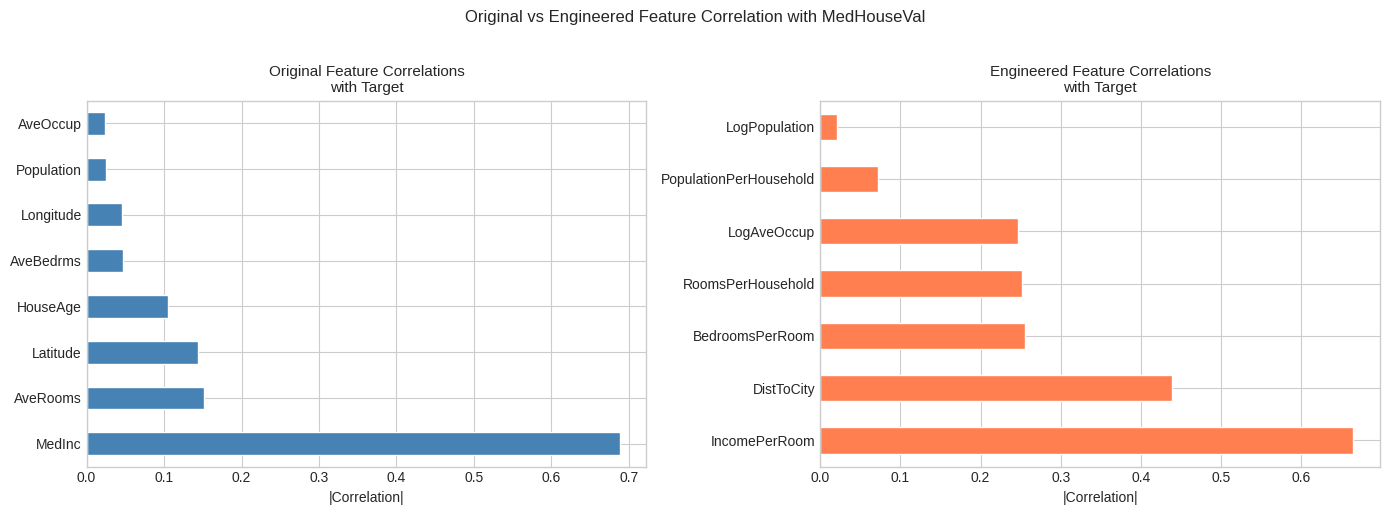

In [7]:
# Verify new features improve correlation with target
orig_corrs = df[housing.feature_names].corrwith(df['MedHouseVal']).abs().sort_values(ascending=False)
eng_corrs  = df_eng[new_features].corrwith(df_eng['MedHouseVal']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orig_corrs.plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Original Feature Correlations\nwith Target', fontsize=11)
axes[0].set_xlabel('|Correlation|')

eng_corrs.plot.barh(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Engineered Feature Correlations\nwith Target', fontsize=11)
axes[1].set_xlabel('|Correlation|')

plt.suptitle('Original vs Engineered Feature Correlation with MedHouseVal', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 5. Build Preprocessing Pipeline

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# All features are numeric — simple pipeline
feature_cols = (
    housing.feature_names +
    ['RoomsPerHousehold','BedroomsPerRoom','PopulationPerHousehold',
     'IncomePerRoom','DistToCity','LogPopulation','LogAveOccup']
)

X = df_eng[feature_cols].copy()
y = df_eng['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Target range: [{y.min():.2f}, {y.max():.2f}]')
print(f'Target mean: {y.mean():.3f}  std: {y.std():.3f}')


Train: (16512, 15)  Test: (4128, 15)
Target range: [0.15, 5.00]
Target mean: 2.069  std: 1.154


## 6. Train and Compare Models

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression':   LinearRegression(),
    'Ridge':               Ridge(alpha=1.0),
    'Lasso':               Lasso(alpha=0.001, max_iter=5000),
    'Decision Tree':       DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsRegressor(n_neighbors=10),
}

results = {}
print(f'{'Model':<22}  {'CV RMSE':>10}  {'CV R²':>10}')
print('-' * 48)
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    rmse_scores = np.sqrt(-cross_val_score(pipe, X_train, y_train, cv=cv,
                                            scoring='neg_mean_squared_error', n_jobs=-1))
    r2_scores   = cross_val_score(pipe, X_train, y_train, cv=cv,
                                   scoring='r2', n_jobs=-1)
    results[name] = {'rmse': rmse_scores, 'r2': r2_scores}
    print(f'{name:<22}  {rmse_scores.mean():10.4f}  {r2_scores.mean():10.4f}')


Model                      CV RMSE       CV R²
------------------------------------------------
Linear Regression           0.6645      0.6694
Ridge                       0.6645      0.6694
Lasso                       0.6632      0.6707
Decision Tree               0.6676      0.6665
Random Forest               0.4986      0.8140
Gradient Boosting           0.5309      0.7890
KNN                         0.5880      0.7412


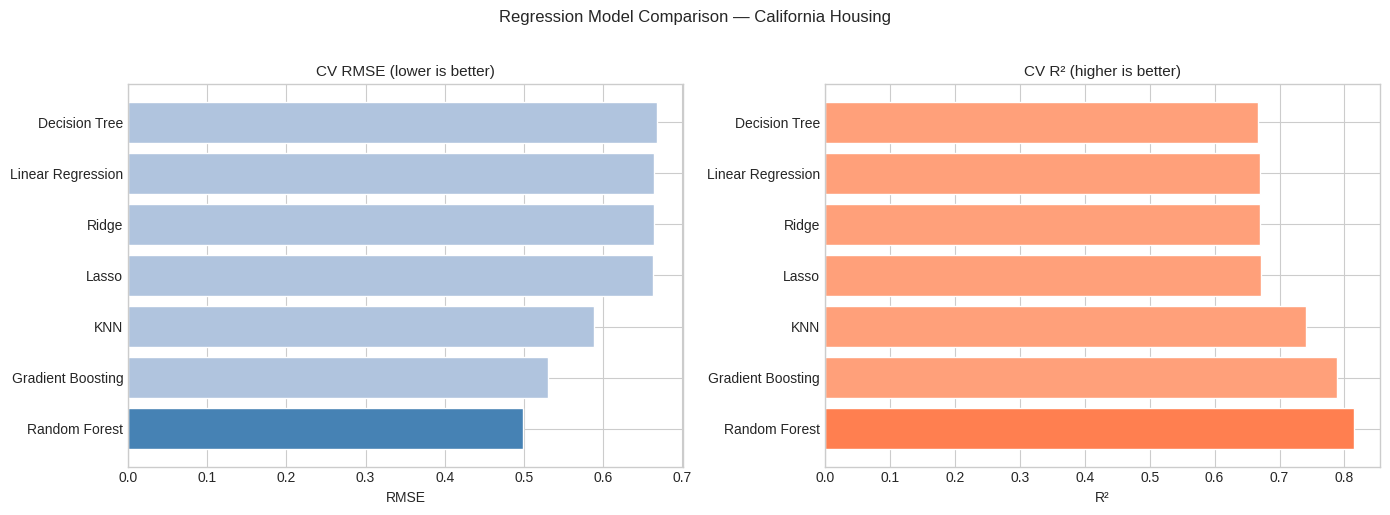

Best model: Random Forest
  CV RMSE: 0.4986  R²: 0.8140


In [10]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
rmses  = [results[n]['rmse'].mean() for n in model_names]
r2s    = [results[n]['r2'].mean()   for n in model_names]

order_rmse = np.argsort(rmses)
order_r2   = np.argsort(r2s)[::-1]

axes[0].barh([model_names[i] for i in order_rmse],
             [rmses[i] for i in order_rmse],
             color=['steelblue' if i==order_rmse[0] else 'lightsteelblue'
                    for i in order_rmse],
             edgecolor='white')
axes[0].set_title('CV RMSE (lower is better)', fontsize=11)
axes[0].set_xlabel('RMSE')

axes[1].barh([model_names[i] for i in order_r2],
             [r2s[i] for i in order_r2],
             color=['coral' if i==order_r2[0] else 'lightsalmon'
                    for i in order_r2],
             edgecolor='white')
axes[1].set_title('CV R² (higher is better)', fontsize=11)
axes[1].set_xlabel('R²')

plt.suptitle('Regression Model Comparison — California Housing', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

best_model_name = model_names[np.argmin(rmses)]
print(f'Best model: {best_model_name}')
print(f'  CV RMSE: {min(rmses):.4f}  R²: {r2s[np.argmin(rmses)]:.4f}')


## 7. Hyperparameter Tuning

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Tune Gradient Boosting (often best on tabular regression)
param_dist = {
    'reg__n_estimators':    randint(100, 600),
    'reg__max_depth':       [3, 4, 5, 6],
    'reg__learning_rate':   uniform(0.01, 0.2),
    'reg__subsample':       uniform(0.6, 0.4),
    'reg__min_samples_leaf':randint(1, 20),
    'reg__max_features':    ['sqrt', 'log2', 0.5, 0.8],
}

gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('reg',  GradientBoostingRegressor(random_state=42))
])

search = RandomizedSearchCV(
    gb_pipe, param_dist,
    n_iter=30, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

best_cv_rmse = -search.best_score_
print(f'Best CV RMSE: {best_cv_rmse:.4f}')
print(f'Best parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')


Best CV RMSE: 0.4486
Best parameters:
  reg__learning_rate: 0.052467822135655234
  reg__max_depth: 6
  reg__max_features: 0.8
  reg__min_samples_leaf: 1
  reg__n_estimators: 559
  reg__subsample: 0.8446612641953124


## 8. Final Model Evaluation

In [12]:
best_pipe = search.best_estimator_
y_pred    = best_pipe.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Adjusted R2
m_t, p_t = X_test.shape
r2_adj = 1 - (1-r2)*(m_t-1)/(m_t-p_t-1)

mape = np.mean(np.abs((y_test - y_pred)/y_test)) * 100

print('=== FINAL TEST SET RESULTS ===')
print(f'MAE:         {mae:.4f}  (${mae*100_000:.0f} average error)')
print(f'RMSE:        {rmse:.4f}  (${rmse*100_000:.0f} RMSE)')
print(f'R²:          {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'Adjusted R²: {r2_adj:.4f}')
print(f'MAPE:        {mape:.2f}%')


=== FINAL TEST SET RESULTS ===
MAE:         0.2845  ($28450 average error)
RMSE:        0.4391  ($43909 RMSE)
R²:          0.8529  (85.3% variance explained)
Adjusted R²: 0.8523
MAPE:        16.26%


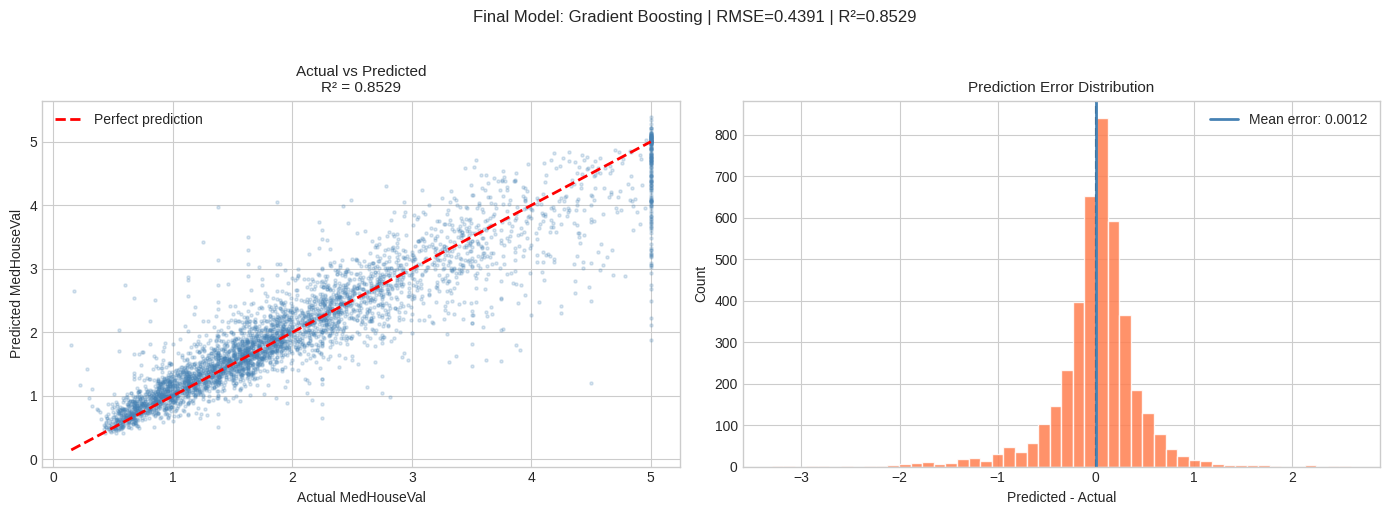

In [13]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=11)
axes[0].set_xlabel('Actual MedHouseVal')
axes[0].set_ylabel('Predicted MedHouseVal')
axes[0].legend()

# Prediction error distribution
errors = y_pred - y_test
axes[1].hist(errors, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axvline(errors.mean(), color='steelblue', linewidth=2,
                label=f'Mean error: {errors.mean():.4f}')
axes[1].set_title('Prediction Error Distribution', fontsize=11)
axes[1].set_xlabel('Predicted - Actual')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Final Model: Gradient Boosting | RMSE={rmse:.4f} | R²={r2:.4f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 9. Residual Analysis

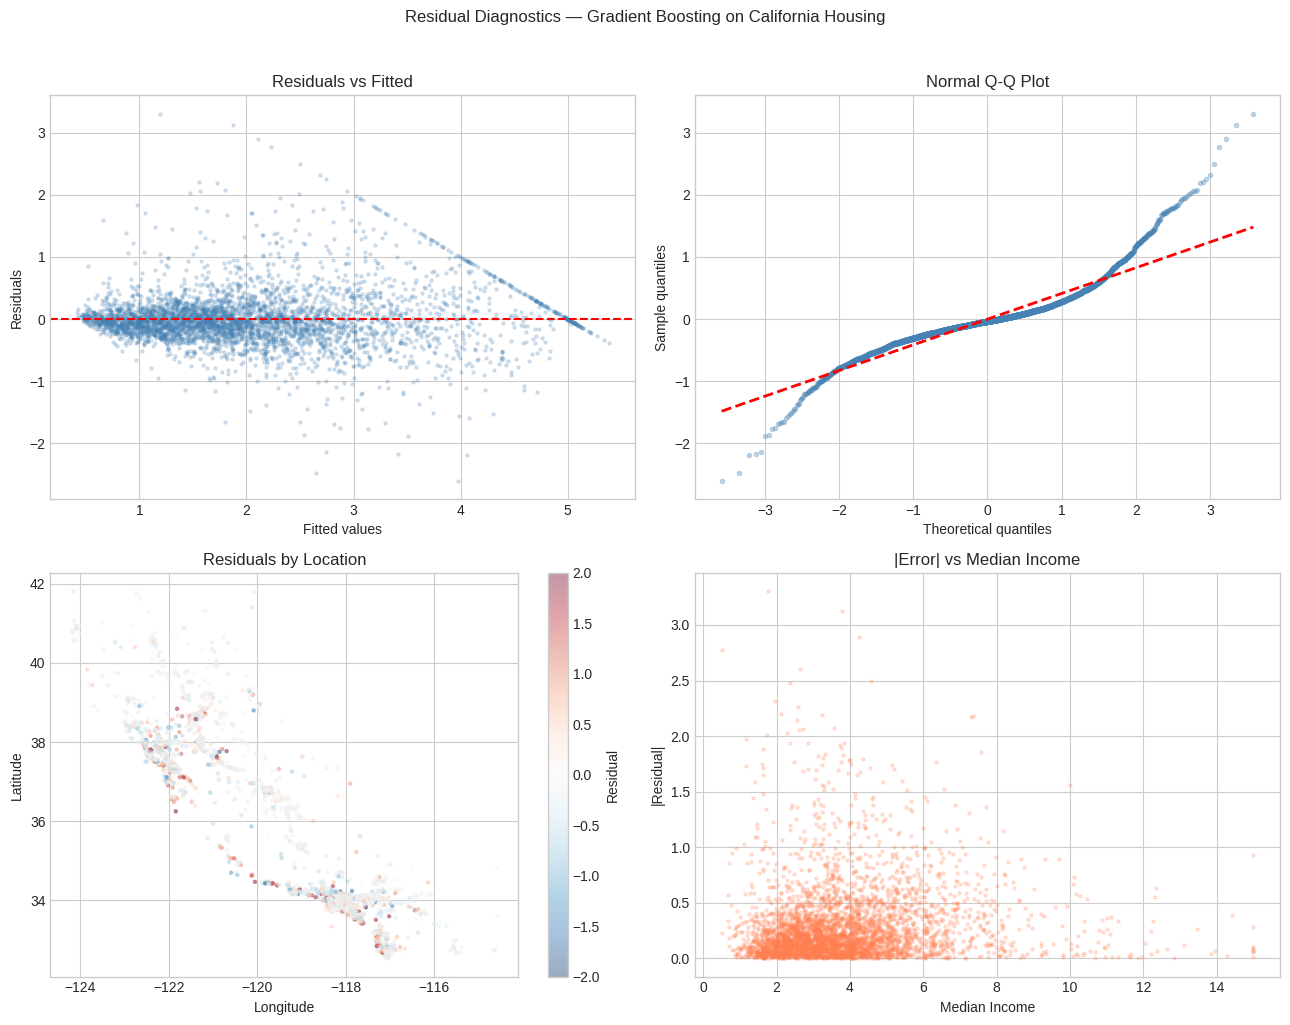

Observations:
  Mean residual:   -0.0012  (should be ~0 — no systematic bias)
  Residual std:    0.4391
  Skewness:        1.032  (good if close to 0)


In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Residuals vs fitted
axes[0,0].scatter(y_pred, residuals, alpha=0.2, s=5, color='steelblue')
axes[0,0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0,0].set_title('Residuals vs Fitted')
axes[0,0].set_xlabel('Fitted values'); axes[0,0].set_ylabel('Residuals')

# Q-Q plot
from scipy.stats import probplot
(osm, osr), (slope, intercept, _) = probplot(residuals, dist='norm')
axes[0,1].plot(osm, osr, 'o', color='steelblue', alpha=0.3, markersize=3)
axes[0,1].plot(osm, slope*np.array(osm)+intercept, 'r--', linewidth=2)
axes[0,1].set_title('Normal Q-Q Plot')
axes[0,1].set_xlabel('Theoretical quantiles'); axes[0,1].set_ylabel('Sample quantiles')

# Residuals by geographic location
X_test_df = X_test.copy()
sc = axes[1,0].scatter(X_test_df['Longitude'], X_test_df['Latitude'],
                        c=residuals, cmap='RdBu_r',
                        s=5, alpha=0.4, vmin=-2, vmax=2)
plt.colorbar(sc, ax=axes[1,0], label='Residual')
axes[1,0].set_title('Residuals by Location')
axes[1,0].set_xlabel('Longitude'); axes[1,0].set_ylabel('Latitude')

# Absolute error vs income
axes[1,1].scatter(X_test_df['MedInc'], np.abs(residuals),
                   alpha=0.2, s=5, color='coral')
axes[1,1].set_title('|Error| vs Median Income')
axes[1,1].set_xlabel('Median Income'); axes[1,1].set_ylabel('|Residual|')

plt.suptitle('Residual Diagnostics — Gradient Boosting on California Housing', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Observations:')
print(f'  Mean residual:   {residuals.mean():.4f}  (should be ~0 — no systematic bias)')
print(f'  Residual std:    {residuals.std():.4f}')
print(f'  Skewness:        {pd.Series(residuals).skew():.3f}  (good if close to 0)')


## 10. Feature Importance and Insights

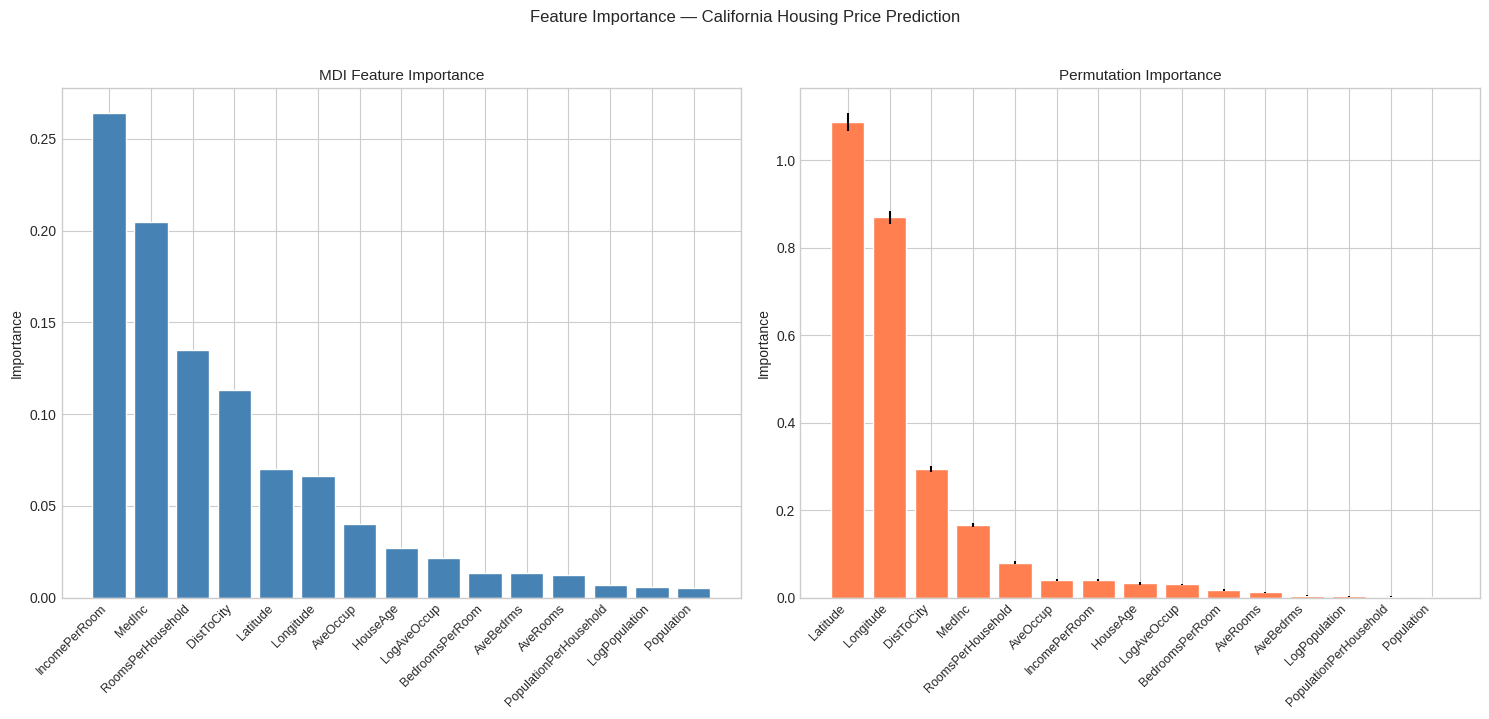

Top 5 features by permutation importance:
  1. Latitude                       1.0886 ± 0.0206
  2. Longitude                      0.8696 ± 0.0151
  3. DistToCity                     0.2945 ± 0.0060
  4. MedInc                         0.1668 ± 0.0051
  5. RoomsPerHousehold              0.0804 ± 0.0033


In [15]:
from sklearn.inspection import permutation_importance

gb_model     = best_pipe.named_steps['reg']
X_test_prep  = best_pipe.named_steps['prep'].transform(X_test)

# MDI importances
importances_mdi = gb_model.feature_importances_

# Permutation importances
perm = permutation_importance(gb_model, X_test_prep, y_test,
                               n_repeats=15, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, imp, err, title, color in [
    (axes[0], importances_mdi, None, 'MDI Feature Importance', 'steelblue'),
    (axes[1], perm.importances_mean, perm.importances_std, 'Permutation Importance', 'coral'),
]:
    order = np.argsort(imp)[::-1]
    if err is not None:
        ax.bar(range(len(feature_cols)),
               imp[order], yerr=err[order],
               color=color, edgecolor='white')
    else:
        ax.bar(range(len(feature_cols)), imp[order], color=color, edgecolor='white')
    ax.set_xticks(range(len(feature_cols)))
    ax.set_xticklabels([feature_cols[i] for i in order],
                        rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Importance')

plt.suptitle('Feature Importance — California Housing Price Prediction', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Top 5 features by permutation importance:')
top5 = np.argsort(perm.importances_mean)[::-1][:5]
for i, idx in enumerate(top5, 1):
    print(f'  {i}. {feature_cols[idx]:<30} {perm.importances_mean[idx]:.4f} ± {perm.importances_std[idx]:.4f}')


## 11. Key Takeaways

**What the data tells us:**

1. **Median income is the strongest predictor** — wealthier neighborhoods have dramatically    higher house prices. This is the single most informative feature.

2. **Location (lat/lon) matters enormously** — the geographic patterns show    coastal areas (SF Bay, LA) command significant premiums.    DistToCity captures this but raw lat/lon also contributes.

3. **RoomsPerHousehold outperforms AveRooms** — the engineered ratio feature is a better    proxy for actual living space because it accounts for occupancy.

4. **The target has a ceiling at 5.0** ($500,000) — this causes the model to underpredict    on expensive areas. Real-world data would not have this cap.

5. **Gradient Boosting beat all other models** — tree ensembles with sequential correction    are the state-of-the-art for tabular regression.

**What we learned about the ML process:**

- EDA + geographic visualization revealed that location is a critical signal
- Ratio features (RoomsPerHousehold, IncomePerRoom) are more informative than raw counts
- Log transforms reduced skewness in Population and AveOccup, helping linear models
- Gradient Boosting outperforms Random Forest on this dataset —   the sequential correction helps fit the income-price relationship
- Residual analysis shows systematic underprediction at high prices (capping artifact)
- MAPE is more interpretable than RMSE for business communication   ('predictions off by X% on average')


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
